# The delta tilt method

A three-panel illustration of the delta method with a **reference-day depth limit**, following the supplied schematic. Run all cells on Katana to choose **random real eddy-days** from the confirmed vertical profiles. Set `N_IMAGES` to the number of figures you want. Change `SEED` for another batch, or set `EDDY_ID` and optionally `REFERENCE_DAY` to choose one yourself. The selected IDs and days are printed below. Sampling visits randomly ordered eddies once per round before drawing additional days from them; eddy-day pairs never repeat. Setting both `EDDY_ID` and `REFERENCE_DAY` produces just that one example. Selection requires five consecutive usable profiles and a finite, nonzero depth-limited tilt; it is for illustration, not an unbiased population sample.

**a)** Five daily centre profiles. **b)** Reconstruct a representative profile from mean depth increments, then fit a variance-weighted 3-D line. **c)** Compare that fitted tilt with the reference day's horizontal extent.

The fit uses both horizontal coordinates. For display, all panels project onto its horizontal axis, positive from shallow to deep; this preserves the fitted horizontal tilt distance. The arrow points **deep to shallow**, as does `TiltDir`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO = next(p for p in (HERE, *HERE.parents) if (p / 'seacofs_eddy_dataset_modular').is_dir())
OUT = REPO / 'seacofs_eddy_tilt_analysis' / 'delta_tilt_method'
sys.path.insert(0, str(OUT))
from delta_sensitivity_tools import increments, fit_snapshot, scan_projected_extent_differences

SEED = 5                # Change this to try another random batch
N_IMAGES = 3             # Number of random eddy-day schematics
EDDY_ID = None             # None = random eddy; otherwise enter an Eddy ID
REFERENCE_DAY = None       # None = random eligible day within that eddy
PROFILE_PATH = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_profiles_confirmed/profiles.parquet')
NUM = 5                   # Centred five-day window: k-2 ... k+2
TEMPORAL_SIGMA_DAYS = 1.0
DEPTH_INT = 10
MAX_DEPTH = 1000
MIN_DEPTH_RANGE = 200
MIN_POINTS = 5
BEARING_OFFSET = 20.0
EPS = 1e-10
SAVE = False

# Optional expensive full-dataset search, executed only in the bottom section.
RUN_DIFFERENCE_SEARCH = False
TOP_N_DIFFERENCES = 60     # Number of largest-mismatch schematics to display

In [2]:
# Load once, then choose unique actual eddy-day windows.
from collections import deque
from IPython.display import display

if not isinstance(N_IMAGES, int) or isinstance(N_IMAGES, bool) or N_IMAGES < 1:
    raise ValueError('N_IMAGES must be a positive integer.')
if REFERENCE_DAY is not None and EDDY_ID is None:
    raise ValueError('Set EDDY_ID as well when choosing REFERENCE_DAY.')
all_profiles = pd.read_parquet(PROFILE_PATH, columns=['Eddy', 'Day', 'Depth', 'xc', 'yc'])
profiles = all_profiles  # Preserve the full dataset for the optional search.
if EDDY_ID is not None:
    profiles = profiles.loc[profiles.Eddy.eq(EDDY_ID)].copy()
if profiles.empty:
    raise ValueError('No profiles found for the requested selection.')

rng = np.random.default_rng(SEED)
target = np.arange(0, MAX_DEPTH + DEPTH_INT, DEPTH_INT)
view = profiles.assign(Depth=profiles.Depth.abs())
view = view.loc[view.Depth.le(MAX_DEPTH)].copy()
view['finite'] = np.isfinite(view[['Depth', 'xc', 'yc']].to_numpy()).all(axis=1)
coverage = view.groupby(['Eddy', 'Day']).agg(
    shallow=('Depth', 'min'), deep=('Depth', 'max'),
    levels=('Depth', 'size'), unique_levels=('Depth', 'nunique'), finite=('finite', 'all'))
coverage['first'] = np.ceil(coverage.shallow / DEPTH_INT) * DEPTH_INT
coverage['last'] = np.floor(coverage.deep / DEPTH_INT) * DEPTH_INT - DEPTH_INT
coverage = coverage.loc[coverage.finite & coverage.levels.eq(coverage.unique_levels)
    & coverage.levels.ge(2) & (coverage['last'] - coverage['first']).ge(MIN_DEPTH_RANGE)
    & ((coverage['last'] - coverage['first']) / DEPTH_INT + 1).ge(MIN_POINTS)]
candidates = {}
for eddy, g in coverage.groupby(level='Eddy'):
    usable = set(g.index.get_level_values('Day').astype(int))
    days = set(usable)
    for offset in range(-(NUM // 2), NUM // 2 + 1):
        days &= {day - offset for day in usable}
    if REFERENCE_DAY is not None:
        days &= {int(REFERENCE_DAY)}
    if days:
        candidates[int(eddy)] = iter(rng.permutation(sorted(days)))

# Spread the batch across eddies, then revisit them if more images are requested.
queue = deque(rng.permutation(sorted(candidates)))
requested = 1 if REFERENCE_DAY is not None else N_IMAGES
selected = []
while queue and len(selected) < requested:
    eddy = int(queue.popleft())
    for day in candidates[eddy]:
        day = int(day)
        trial = profiles.loc[profiles.Eddy.eq(eddy) & profiles.Day.between(day - NUM // 2, day + NUM // 2)]
        dx, dy = increments(trial, DEPTH_INT, MAX_DEPTH)
        result = fit_snapshot(dx, dy, day, sigma=TEMPORAL_SIGMA_DAYS,
            half_window=NUM // 2, min_depth_range=MIN_DEPTH_RANGE,
            min_points=MIN_POINTS, bearing_offset=BEARING_OFFSET, eps=EPS)
        if result is not None and np.isfinite([result['TiltDis'], result['TiltDir']]).all() and result['TiltDis'] > EPS:
            selected.append((eddy, day))
            queue.append(eddy)
            break
if not selected:
    raise ValueError('No eligible examples found. Choose another Eddy/Day or check depth coverage.')
if len(selected) < requested:
    print(f'Only {len(selected)} eligible unique examples are available; requested {requested}.')
samples = pd.DataFrame(selected, columns=['Eddy', 'Day'])
print(f'Selected {len(samples)} examples from {samples.Eddy.nunique()} eddies; seed {SEED}')
display(samples)

Selected 3 examples from 3 eddies; seed 5


,Eddy,Day
0,2103,7923
1,2000,7636
2,1864,7169


## Reference-day-limited calculation

1. Interpolate each daily centreline to 10 m depths **within its observed range**.
2. Calculate adjacent-depth increments $\delta x_d(z)$ and $\delta y_d(z)$.
**Before averaging**, retain only depth intervals whose two endpoints are inside the reference day’s observed profile range (also capped by `MAX_DEPTH`). Neighbouring days cannot extend that range.

3. Average those increments across five calendar days with Gaussian sigma = 1 day, then cumulatively sum them to form $\widetilde{x}(z),\widetilde{y}(z)$. Weights renormalize over available days at each depth. This removes each day's horizontal translation.
4. Weight each depth by $w(z)=1/[\mathrm{Var}(\delta x)+\mathrm{Var}(\delta y)+10^{-10}]$, using sample variances across days. Fit the leading singular vector of the weighted, centred $(\widetilde{x},\widetilde{y},z)$ coordinates.
5. Intersect that line with the shallowest and deepest retained fit depths. Their horizontal separation is `TiltDis`; the deep-to-shallow bearing plus the configured 20° rotation is `TiltDir`.

Implementation details retained here: missing days stay missing; a single available increment cannot supply a sample variance. Cumulative increments are labelled by the **upper** depth of each interval, so an 850 m profile ends at a fit label of 840 m. The fit uses horizontal kilometres and depth metres exactly as the production code does. Display recentering does not alter the fit or distance.

This correction is implemented locally in `delta_sensitivity_tools.fit_snapshot`; the production pipeline is deliberately unchanged. A missing reference profile or insufficient retained depth support gives no estimate. With the retained upper-interval labels, a 0–200 m profile spans labels 0–190 m and fails `MIN_DEPTH_RANGE=200`.


In [13]:
def plot_schematic(EDDY, DAY, profiles):
    window_days = np.arange(DAY - NUM // 2, DAY + NUM // 2 + 1)
    window = profiles.assign(Depth=profiles.Depth.abs())
    window = window.loc[window.Depth.le(MAX_DEPTH)].sort_values(['Day', 'Depth'])
    print(f'Observed eddy {EDDY}, reference Day {DAY}')
    dx, dy = increments(profiles, DEPTH_INT, MAX_DEPTH)
    fit = fit_snapshot(dx, dy, DAY, sigma=TEMPORAL_SIGMA_DAYS,
        half_window=NUM // 2, min_depth_range=MIN_DEPTH_RANGE,
        min_points=MIN_POINTS, bearing_offset=BEARING_OFFSET, eps=EPS)
    if fit is None or fit['TiltDis'] < EPS:
        raise ValueError('Reference day has insufficient depth support or zero tilt.')
    trace = fit['trace']
    points = trace[['x', 'y', 'Depth']].to_numpy()
    weights = trace.weight.to_numpy() / trace.weight.max()
    top, bottom = fit['ends']
    tilt_distance, tilt_direction = fit['TiltDis'], fit['TiltDir']
    axis = (bottom[:2] - top[:2]) / tilt_distance
    reference = window.loc[window.Day.eq(DAY)]
    reference_top, reference_bottom = reference.Depth.min(), reference.Depth.max()
    assert trace.Depth.min() >= reference_top
    assert trace.Depth.max() + DEPTH_INT <= reference_bottom + 1e-8
    print(f'Reference depth: {reference_top:.1f}–{reference_bottom:.1f} m; '
          f'fit labels: {top[2]:.1f}–{bottom[2]:.1f} m; TiltDis = {tilt_distance:.2f} km')

    plt.rcParams.update({'font.size': 11, 'axes.spines.top': True, 'axes.spines.right': True})
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
    # fig.suptitle(f'Eddy {EDDY} · reference Day {DAY}', y=1.08, fontsize=12)
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.23, top=0.82, wspace=0.13)
    colors = ['#5399cf', '#ff993e', '#54ad55', '#df2429', '#a989d4', '#a77b6b', '#ef7bc9']
    ref = window.loc[window.Day.eq(DAY)].sort_values('Depth')
    ref_xy = ref[['xc', 'yc']].to_numpy()
    # for ax in axs:
    #     ax.axhline(reference_bottom, color='grey', ls=':', lw=1, alpha=0.7)
    for j, day in enumerate(window_days):
        color = colors[(3 + int(day - DAY)) % len(colors)]
        g = window.loc[window.Day.eq(day)]
        if g.empty:
            continue
        offset = int(day - DAY)
        label = 'Day k' if offset == 0 else f'Day k{offset:+d}'
        xy0 = g[['xc', 'yc']].iloc[0].to_numpy()
        # axs[0].plot(g[['xc', 'yc']].to_numpy() @ axis - xy0, g.Depth, color=color,
        #             lw=2.8 if offset == 0 else 1.1, label=label)
        axs[0].plot(
            (g[['xc', 'yc']].to_numpy() - xy0) @ axis,
            g.Depth,
            color=color,
            lw=2.8 if offset == 0 else 1.1,
            label=label
        )
    axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=5, fontsize=8, frameon=False)
    axs[0].set_xlabel('Projected centre position (km)')
    axs[0].set_ylabel('Depth (m)')

    origin = points[0, :2] @ axis
    s = points[:, :2] @ axis - origin
    fit_s = np.array([top[:2] @ axis, bottom[:2] @ axis]) - origin
    fit_z = np.array([top[2], bottom[2]])
    raw_s = (ref_xy - ref_xy[0]) @ axis
    for ax in axs[1:]:
        ax.plot(s, points[:, 2], color='blue', lw=2, label='Mean-increment profile')
        ax.plot(fit_s, fit_z, 'k--', lw=2, label='Weighted line fit')
        ax.set_xlabel('Relative displacement (km)')
    # Ribbon width encodes the normalized weights, not positional uncertainty.
    width = weights * max(tilt_distance * 0.30, 1)
    axs[1].fill_betweenx(points[:, 2], s - width, s + width, color='#6baed6', alpha=0.5,
                         linewidth=0, label='Width ∝ fit weight')
    axs[1].lines[0].set_zorder(4)
    span = max(tilt_distance, np.ptp(raw_s), 1)
    arrow_x = fit_s - 0.10 * span
    axs[1].annotate('', xy=(arrow_x[0], fit_z[0] + 110),
                    xytext=(arrow_x[1], fit_z[1] - 60),
                    arrowprops={'arrowstyle': '-|>', 'color': 'black', 'lw': 2, 'mutation_scale': 19})
    axs[1].text(arrow_x.mean() - 0.09 * span, fit_z.mean(), 'Tilt direction', ha='right')
    axs[2].plot(raw_s, ref.Depth, color='#df2429', lw=2.5, label='Reference day k')

    def bracket(ax, left, right, depth, label, color, ends):
        ax.plot([left, right], [depth, depth], color=color, lw=1.4, clip_on=False)
        for x, end in zip([left, right], ends):
            ax.plot([x, x], [depth - 15, end], color=color, lw=1.3, clip_on=False)
        ax.text((left + right) / 2, depth - 18, label, ha='center', va='bottom', color=color)

    bracket(axs[1], *fit_s, -70, f'Tilt distance: {tilt_distance:.1f} km', 'black', fit_z)
    bracket(axs[2], *fit_s, -70, f'', 'black', fit_z)
        
    imin, imax = np.argmin(raw_s), np.argmax(raw_s)
    bracket(axs[2], raw_s[imin], raw_s[imax], -155,
            f'Max projected extent: {np.ptp(raw_s):.1f} km', '#df2429',
            [ref.Depth.iloc[imin], ref.Depth.iloc[imax]])
    lo = min(s.min() - width.max(), raw_s.min(), arrow_x.min()) - 0.20 * span
    hi = max(s.max() + width.max(), raw_s.max()) + 0.13 * span
    for ax in axs[1:]:
        ax.set_xlim(lo, hi)
    for label, ax in zip(['a)', 'b)', 'c)'], axs):
        ax.set_ylim(MAX_DEPTH, -35)
        ax.text(-0.07, 1.02, label, transform=ax.transAxes, fontweight='bold', fontsize=13)
    axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=9, frameon=False)
    # axs[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=8, frameon=False)
    if SAVE:
        tag = f'eddy_{EDDY}_day_{DAY}'
        for ext in ['png', 'pdf']:
            fig.savefig(OUT / f'delta_tilt_schematic_{tag}.{ext}', dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return {'Eddy': EDDY, 'Day': DAY, 'TiltDis': tilt_distance, 'TiltDir': tilt_direction,
            'ReferenceDepthMax': reference_bottom, 'FitDepthMax': bottom[2],
            'MaxProjectedExtent': float(np.ptp(raw_s)),
            'AbsoluteDifference': float(abs(np.ptp(raw_s) - tilt_distance))}

Observed eddy 2103, reference Day 7923
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 3.69 km


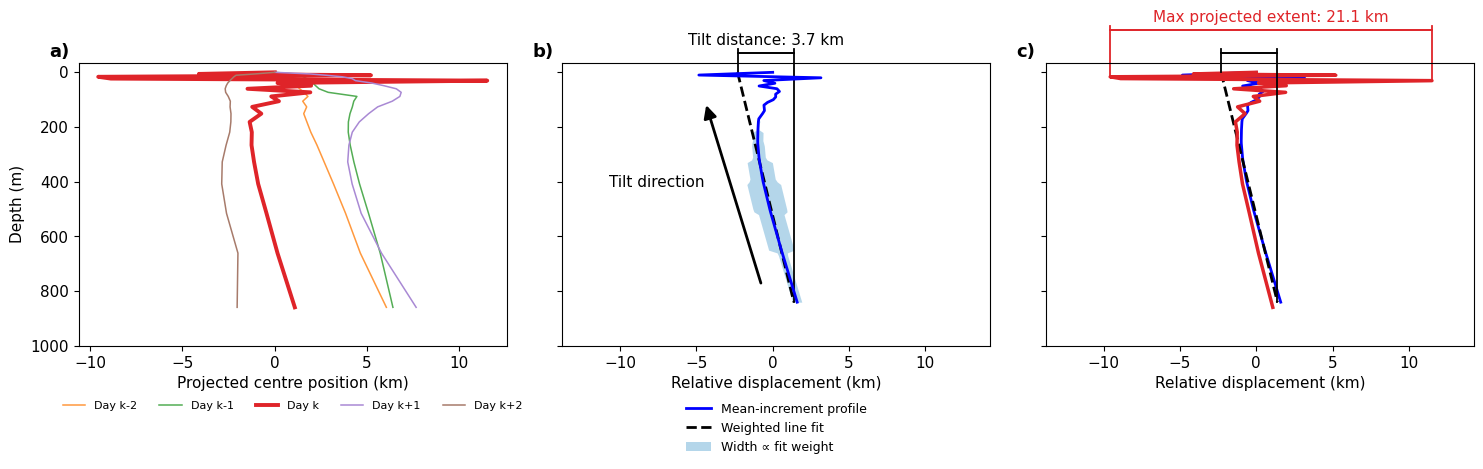

Observed eddy 2000, reference Day 7636
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 15.17 km


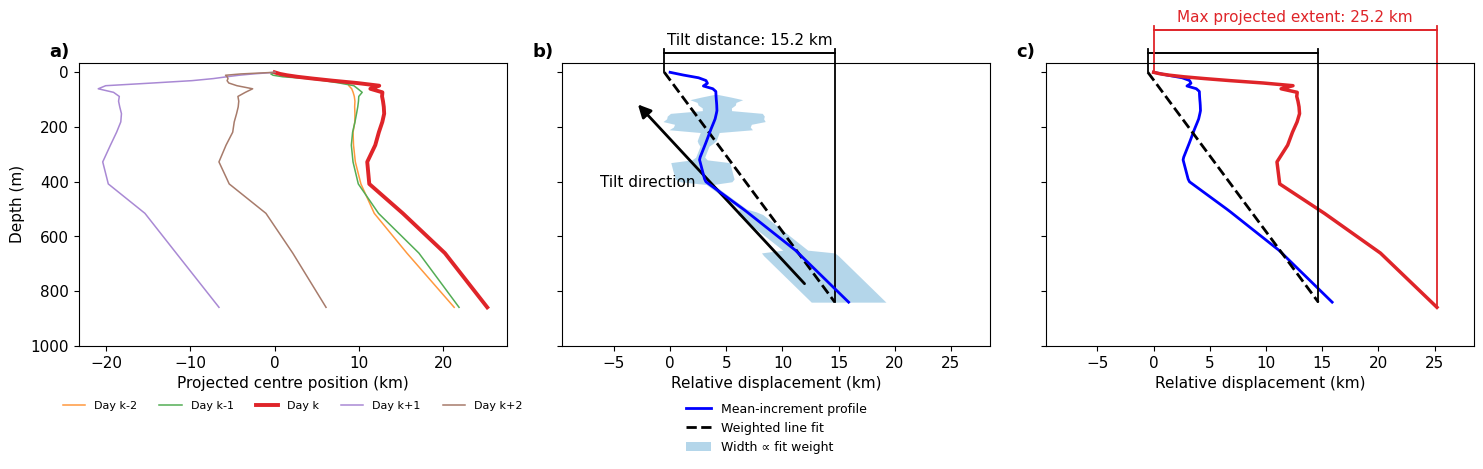

Observed eddy 1864, reference Day 7169
Reference depth: 0.0–858.9 m; fit labels: 0.0–840.0 m; TiltDis = 50.32 km


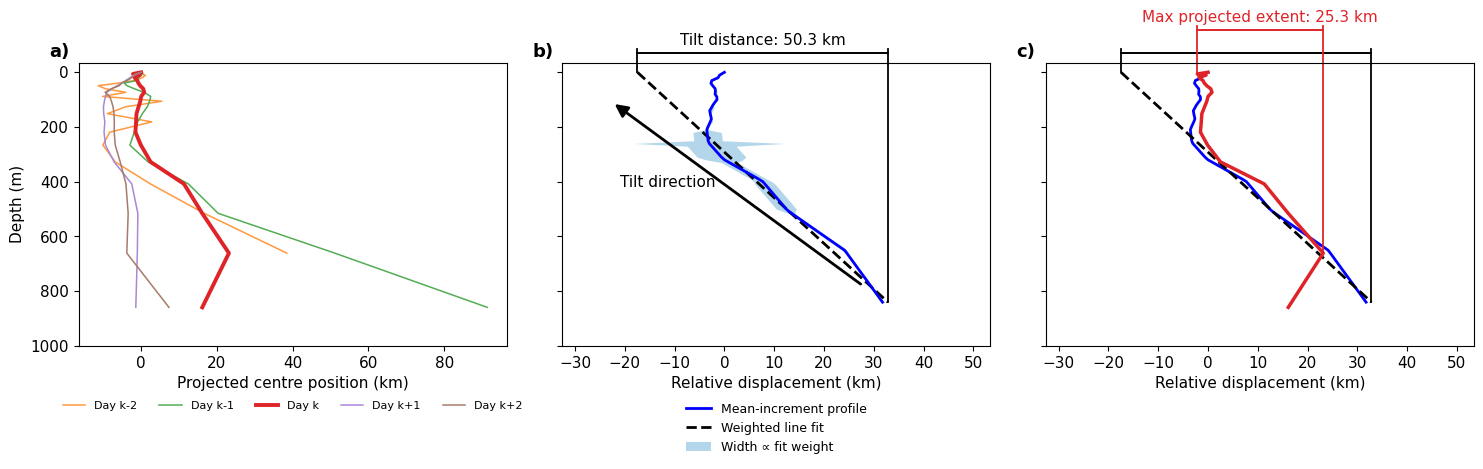

,Eddy,Day,TiltDis,TiltDir,ReferenceDepthMax,FitDepthMax,MaxProjectedExtent,AbsoluteDifference
0,2103,7923,3.69,65.0,858.918478,840.0,21.070723,17.381902
1,2000,7636,15.17,4.9,858.918478,840.0,25.214181,10.046020
2,1864,7169,50.32,201.0,858.918478,840.0,25.313785,25.005147


In [14]:
# One unchanged three-panel schematic per sampled eddy-day.
results = []
for EDDY, DAY in selected:
    trial = profiles.loc[profiles.Eddy.eq(EDDY) & profiles.Day.between(DAY - NUM // 2, DAY + NUM // 2)]
    results.append(plot_schematic(EDDY, DAY, trial))
results = pd.DataFrame(results)
display(results.round({'TiltDis': 2, 'TiltDir': 1}))
if SAVE:
    results.to_csv(OUT / 'delta_tilt_schematic_selected_examples.csv', index=False)
    print(f'Saved {len(results)} PNG/PDF pairs and selection table to {OUT}')

**Reading panel c.** The red bracket is the reference day's maximum minus minimum position **projected onto the fitted tilt axis**. It illustrates the older schematic's “max displacement” comparison, but is not necessarily the maximum pairwise 2-D displacement or maximum displacement from the surface. The black bracket is the horizontal endpoint separation of the weighted fit to the reconstructed, smoothed profile. They need not agree: the reference profile can curve, and the delta method averages increments across days and downweights inconsistent increments.

The blue ribbon in b encodes relative fit weights; it is **not a confidence interval**. Missing days and differing profile depths can change the number of contributions with depth. Panel a still displays the full neighbouring profiles for context; reconstruction and fitting in b/c use only the reference day’s supported depth intervals. This notebook tests the corrected approach without modifying the production pipeline.

## Optional: largest projected-extent versus delta-tilt differences

Set `RUN_DIFFERENCE_SEARCH=True` in the first controls cell to scan **all eddy-days in `PROFILE_PATH`**, regardless of `EDDY_ID`, `REFERENCE_DAY`, `N_IMAGES` or the random sample. The score is

$$\left|\mathrm{maximum\ projected\ extent}-\mathrm{delta\ tilt\ distance}\right|\quad\text{(km)}.$$

For each day, projected extent uses that day's centres projected onto **its own delta fit's horizontal axis**, exactly as in panel c. It is not maximum pairwise 2-D separation. The scan uses the current depth/window/weight settings and retains the reference-day depth limit. It includes every observed day with a valid nonzero fit; unlike the random illustration sampler, it does not require every neighbouring day to pass the full-depth screening. Missing or invalid fits and track edges without a centred window are excluded.

This can take time. Depth increments are computed once per eddy, and progress prints every 100 eddies. Results remain in `difference_ranking`; no new cache is created. Change `TOP_N_DIFFERENCES` and rerun just the **last plotting cell** to inspect more or fewer results without rescanning. Multiple top-ranked days may belong to the same eddy. Positive `Difference` means projected extent exceeds delta tilt; ranking uses `AbsoluteDifference`.

In [5]:
if RUN_DIFFERENCE_SEARCH:
    def report_search(done, total, valid):
        if done == 1 or done % 100 == 0 or done == total:
            print(f'Scanned {done}/{total} eddies; {valid:,} valid eddy-days', flush=True)

    difference_search_settings = dict(depth_int=DEPTH_INT, max_depth=MAX_DEPTH,
        sigma=TEMPORAL_SIGMA_DAYS, half_window=NUM // 2,
        min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
        bearing_offset=BEARING_OFFSET, eps=EPS)
    difference_ranking = scan_projected_extent_differences(
        all_profiles, **difference_search_settings, progress=report_search)
    print(f'Ranked {len(difference_ranking):,} eddy-days by absolute difference (km).')
    if SAVE:
        difference_ranking.to_csv(OUT / 'delta_tilt_schematic_difference_ranking.csv', index=False)
else:
    print('Full-dataset difference search skipped. Set RUN_DIFFERENCE_SEARCH=True to enable it.')

Full-dataset difference search skipped. Set RUN_DIFFERENCE_SEARCH=True to enable it.


In [6]:
if RUN_DIFFERENCE_SEARCH:
    if not isinstance(TOP_N_DIFFERENCES, int) or isinstance(TOP_N_DIFFERENCES, bool) or TOP_N_DIFFERENCES < 1:
        raise ValueError('TOP_N_DIFFERENCES must be a positive integer.')
    current_settings = dict(depth_int=DEPTH_INT, max_depth=MAX_DEPTH,
        sigma=TEMPORAL_SIGMA_DAYS, half_window=NUM // 2,
        min_depth_range=MIN_DEPTH_RANGE, min_points=MIN_POINTS,
        bearing_offset=BEARING_OFFSET, eps=EPS)
    if current_settings != difference_search_settings:
        raise ValueError('Fit settings changed; rerun the search cell before plotting ranked results.')
    largest_differences = difference_ranking.head(TOP_N_DIFFERENCES)
    display(largest_differences.round(2))
    if len(largest_differences) < TOP_N_DIFFERENCES:
        print(f'Only {len(largest_differences)} valid ranked examples are available.')
    for row in largest_differences.itertuples(index=False):
        print(f'Rank {row.Rank}: Eddy {row.Eddy}, Day {row.Day}; '
              f'absolute difference = {row.AbsoluteDifference:.2f} km '
              f'(extent {row.MaxProjectedExtent:.2f}, delta {row.TiltDis:.2f})')
        trial = all_profiles.loc[all_profiles.Eddy.eq(row.Eddy)
            & all_profiles.Day.between(row.Day - NUM // 2, row.Day + NUM // 2)]
        # plotted = plot_schematic(row.Eddy, row.Day, trial)
        # np.testing.assert_allclose(
        #     [plotted['MaxProjectedExtent'], plotted['TiltDis'], plotted['AbsoluteDifference']],
        #     [row.MaxProjectedExtent, row.TiltDis, row.AbsoluteDifference], rtol=1e-8, atol=1e-8)
        try:
            plotted = plot_schematic(row.Eddy, row.Day, trial)
            np.testing.assert_allclose(
                [plotted['MaxProjectedExtent'], plotted['TiltDis'], plotted['AbsoluteDifference']],
                [row.MaxProjectedExtent, row.TiltDis, row.AbsoluteDifference],
                rtol=1e-8, atol=1e-8
            )
        except Exception:
            continue